# Beta Distribution
### CA2 @ EPS Course

#### Instructors: Dr. Tavassolipour, Dr. Vahabie

---

### Instructions:
-  Replace the placeholders (between <font color="green">`## TODO ##`</font> and <font color="green">`## TODO ##`</font>) with the appropriate details.
- Ensure you run each cell after you've entered your solution.

---

*Full Name:* ...

*SID:* ...

The objective of this notebook is to estimate the probability of getting tails in a coin flip using a Bayesian approach.



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Union
from scipy.integrate import quad #For integral

In [12]:
class BetaDistribution:
    """
    Represents a beta distribution with the given shape parameters.
    """

    def __init__(self, alpha: float, beta: float):
        """
        Args:
            alpha (float): The first shape parameter of the beta distribution.
            beta (float): The second shape parameter of the beta distribution.
        """

        ######################  TODO  ########################
        self.a = alpha
        self.b = beta
        ######################  TODO  ########################

    def pdf(self, x: Union[float, np.ndarray]) -> Union[float, np.ndarray]:
        """
        Calculates the normalized probability density function (PDF) of the beta distribution at the given input value(s).
        Args:
            x (float or np.ndarray): The input value(s) to evaluate the beta distribution PDF at.
        Returns:
            pdf (float or np.ndarray): The normalized probability density function evaluated at the input value(s).
        """
        ######################  TODO  ########################
        return self.__calculate_normalization_constant() * self.__unnormalized_pdf(x)
        ######################  TODO  ########################

    def __unnormalized_pdf(self, x: Union[float, np.ndarray]) -> Union[float, np.ndarray]:
        """
        Calculates the unnormalized probability density function (PDF) of the beta distribution at the given input value(s).

        Args:
            x (float or np.ndarray): The input value(s) to evaluate the unnormalized beta distribution PDF at.

        Returns:
            pdf (float or np.ndarray): The unnormalized probability density function evaluated at the input value(s).
        """
        ######################  TODO  ########################
        return x ** (self.a - 1) * (1 - x) ** (self.b - 1)
        ######################  TODO  ########################

    def __calculate_normalization_constant(self):
        """
        Calculates the normalization constant for the beta distribution.
        This constant is used to ensure that the total probability under the PDF is 1.
        """
        ######################  TODO  ########################
        summation, error = quad(self.__unnormalized_pdf, 0, 1)
        return 1 / summation
        ######################  TODO  ########################

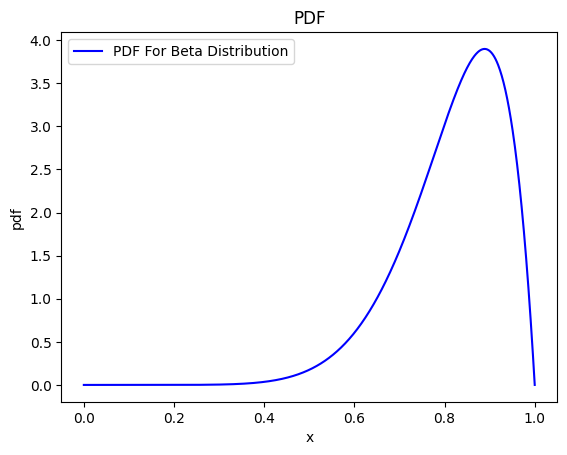

In [ ]:
def plot_beta_dist(beta: BetaDistribution):
    """
    Plots the probability density function of the given beta distribution.

    Args:
        beta (BetaDistribution): The beta distribution instance to plot.
    """
    ######################  TODO  ########################
    # Do not forget to add title, labels, and legend.
    x = np.linspace(0, 1, 1000)
    pdf = beta.pdf(x)
    plt.plot(x, pdf, label = "PDF For Beta Distribution", color = "blue")

    plt.title("PDF")
    plt.xlabel("x")
    plt.ylabel("pdf")
    plt.legend()

    plt.show()
    ######################  TODO  ########################
    
beta = BetaDistribution(9, 2)
plot_beta_dist(beta)

Read the `coint_flips.txt` file and plot the posterior distributions after every 50 trials for two prior probabilities:
1. Uniform distribution 
2. $Beta (4, 10)$

In [46]:
######################  TODO  ########################
coin_flips_file = open("data/coin_flips.txt", "r")
coin_flips_list = [s.split()[0] for s in coin_flips_file]
######################  TODO  ########################

## Prior: Uniform

**Hint:** use `plt.figure(figsize=(25, 20))` and `plt.subplot(4, 5, ...)`

First I put a and b parameters equal to 1 because I want the initial prior distribution to be a uniform distribution(Beta(1, 1) = U(0, 1).) This prior distribution tells that there is no known information and we know nothing about how much the probabilities that the coin comes head or tail are in advance.

 Then I plotted the prior distribution and after that in a loop I iterated over the coin flips list which I created in the former code cell. In this iteration the step is 50 actually, and I slice the list by the update rate equal to 50. Then I plot all the 1000/50 = 20 graphs and we can see the betta distribution progressing and getting thinner and more fit to its mode by each iteration.

C:\Users\Shahab\AppData\Local\Temp\ipykernel_14476\3786585036.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


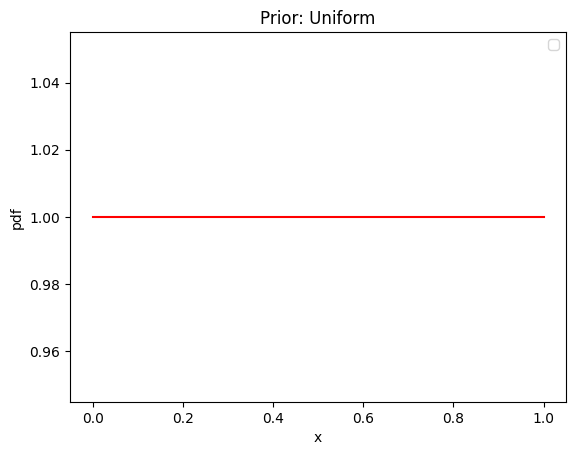

C:\Users\Shahab\AppData\Local\Temp\ipykernel_14476\3786585036.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


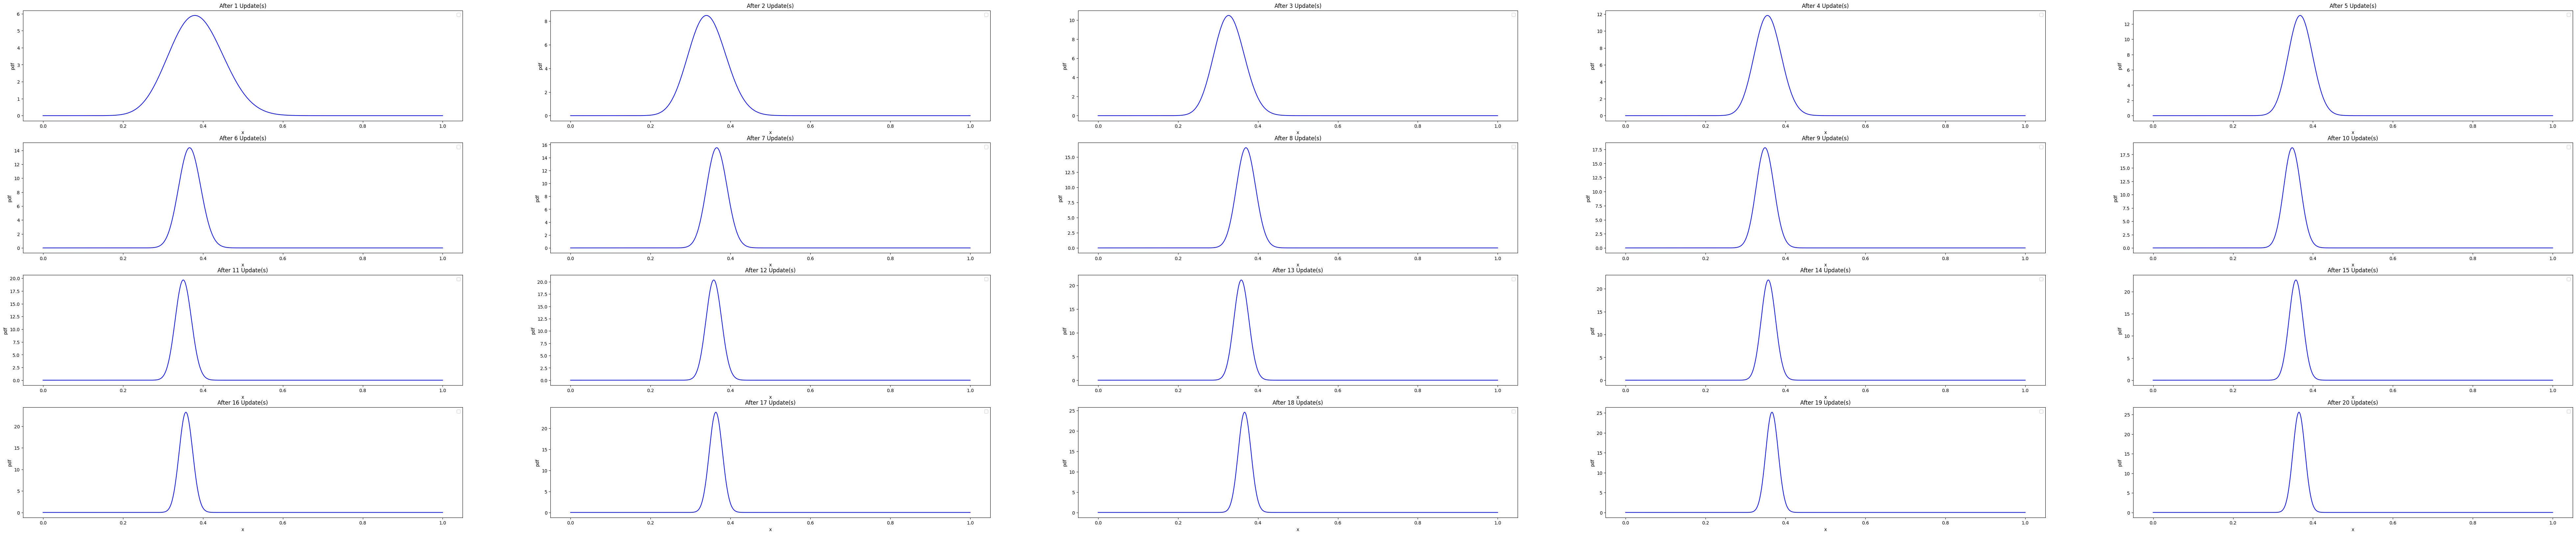

In [ ]:
######################  TODO  ########################
update_rate = 50

#Shaping the prior uniform distribution using a and b parameters:
initial_a = 1
initial_b = 1

beta = BetaDistribution(initial_a, initial_b)
x = np.linspace(0, 1, 1000)
pdf = beta.pdf(x)
plt.plot(x, pdf, color = "red")
plt.title("Prior: Uniform")
plt.xlabel("x")
plt.ylabel("pdf")
plt.legend()
plt.show()

plt.figure(figsize=(25, 20))

for i in range(0, len(coin_flips_list) // update_rate):
    head_count = coin_flips_list[i * 50 : (i + 1) * 50].count('H')
    tail_count = coin_flips_list[i * 50 : (i + 1) * 50].count('T')
    initial_a += head_count; initial_b += tail_count
    
    beta = BetaDistribution(initial_a, initial_b)
    pdf = beta.pdf(x)
    
    plt.subplot(4, 5, i + 1)
    plt.plot(x, pdf, color = "blue")

    plt.title(f"After {i + 1} Update(s)")
    plt.xlabel("x")
    plt.ylabel("pdf")
    plt.legend()
    
plt.show()
######################  TODO  ########################

Now calculate the final posterior mean and variance.

In [59]:
######################  TODO  ########################
final_mean = initial_a / (initial_a + initial_b)
final_variance = initial_a * initial_b / ((initial_a + initial_b + 1) * (initial_a + initial_b) ** 2)
print("Final Mean: %0.10f" %final_mean, "\nFinal Variance: %0.10f" %final_variance)
######################  TODO  ########################

Final Mean: 0.3652694611 
Final Variance: 0.0002311542


## Prior: $Beta(4, 10)$

This part is exactly like the previous part, but has a slight difference. That is the prior distribution. In this part we assume that we know some information about how much the probabilities of the coin are. 

This time we put the prior distribution equal to Beta(4, 10).

C:\Users\Shahab\AppData\Local\Temp\ipykernel_14476\195806407.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


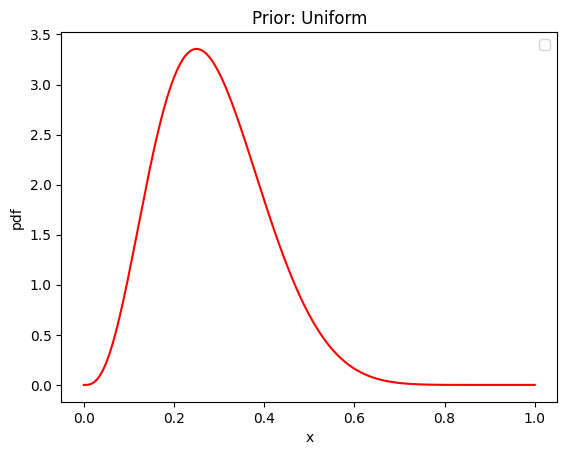

C:\Users\Shahab\AppData\Local\Temp\ipykernel_14476\195806407.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


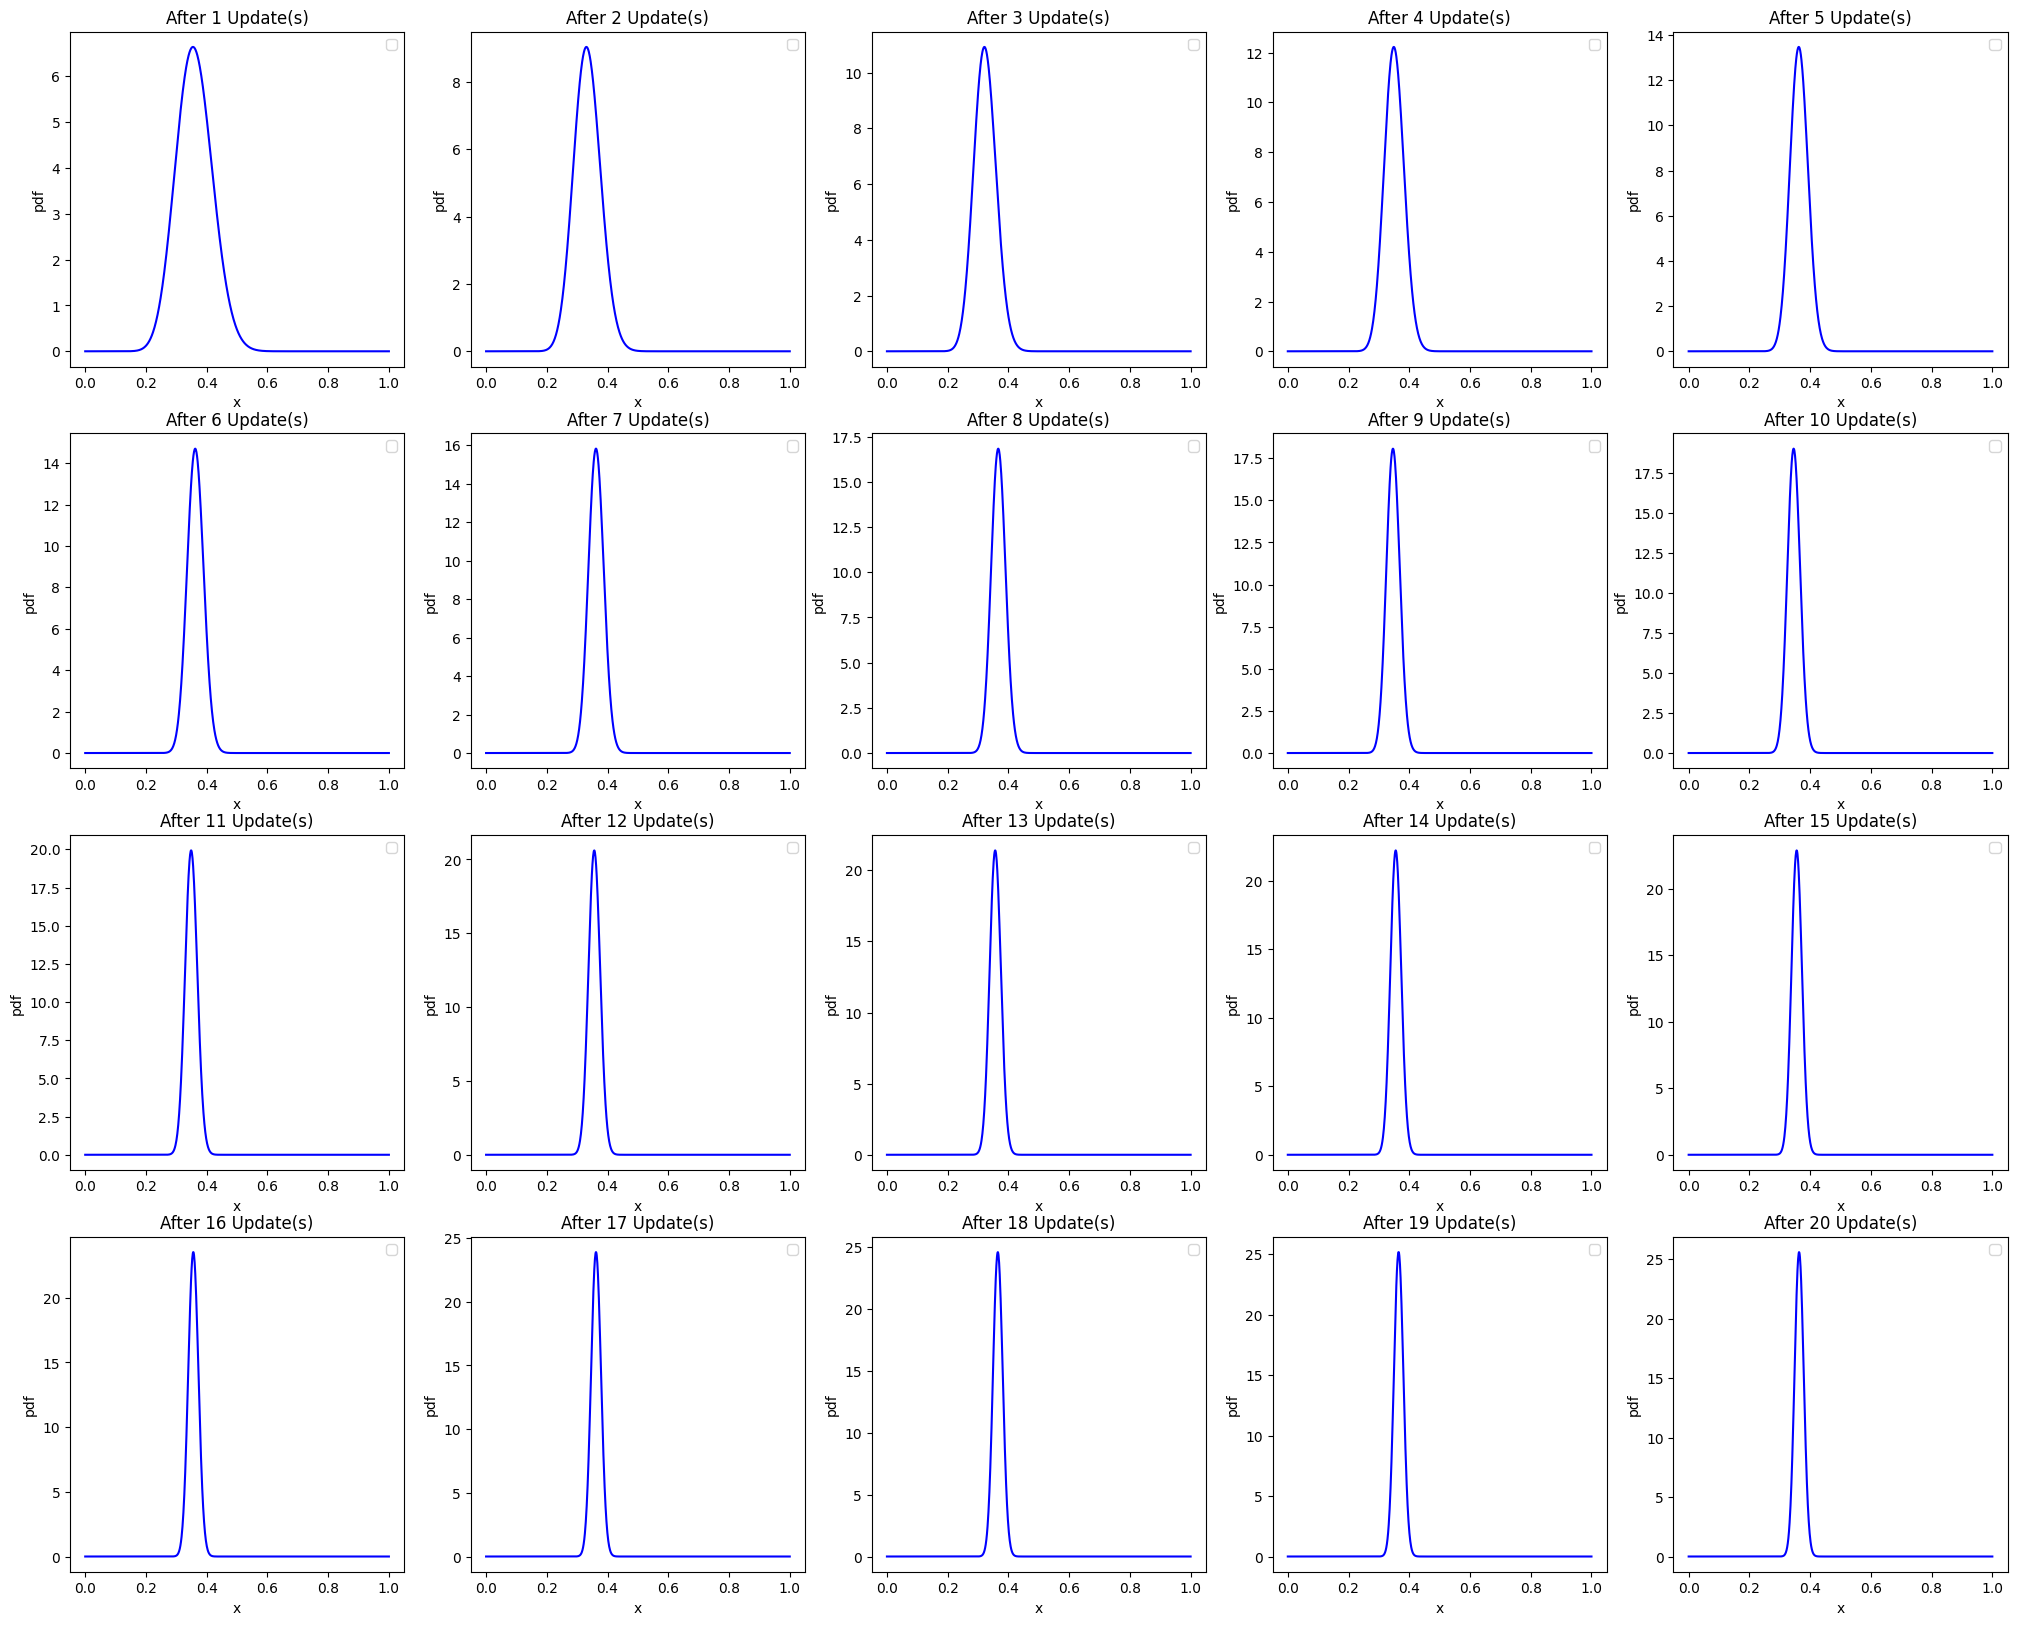

In [60]:
######################  TODO  ########################
#Shaping the prior Beta distribution using a and b parameters:
initial_a = 4
initial_b = 10

beta = BetaDistribution(initial_a, initial_b)
x = np.linspace(0, 1, 1000)
pdf = beta.pdf(x)
plt.plot(x, pdf, color = "red")
plt.title("Prior: Uniform")
plt.xlabel("x")
plt.ylabel("pdf")
plt.legend()
plt.show()

plt.figure(figsize=(25, 20))

for i in range(0, len(coin_flips_list) // update_rate):
    head_count = coin_flips_list[i * 50 : (i + 1) * 50].count('H')
    tail_count = coin_flips_list[i * 50 : (i + 1) * 50].count('T')
    initial_a += head_count; initial_b += tail_count
    
    beta = BetaDistribution(initial_a, initial_b)
    pdf = beta.pdf(x)
    
    plt.subplot(4, 5, i + 1)
    plt.plot(x, pdf, color = "blue")

    plt.title(f"After {i + 1} Update(s)")
    plt.xlabel("x")
    plt.ylabel("pdf")
    plt.legend()
    
plt.show()
######################  TODO  ########################

Now calculate the final posterior mean and variance.

In [61]:
######################  TODO  ########################
final_mean = initial_a / (initial_a + initial_b)
final_variance = initial_a * initial_b / ((initial_a + initial_b + 1) * (initial_a + initial_b) ** 2)
print("Final Mean: %0.10f" %final_mean, "\nFinal Variance: %0.10f" %final_variance)
######################  TODO  ########################

Final Mean: 0.3639053254 
Final Variance: 0.0002280574
